# Text-Segmentierung Masek-Lanuage-Modell

Fine-Tuning des Masked-Language-Modells FacebookAI/xlm-roberta-base zur Segmentierung mittels Klassifikation

**Voraussetzungen**

Environment: mlm

Zur Erstellung des Datensatzes für das Training muss für die verwendeten PDF-Dokumente zurvor die Vorverarbeitung und Erstellung der Dataframes über das Notebook Preparation.ipynb ausgeführt werden.

**Versuchsaufbau**

Durch das Masked-Language-Modell werden Eingaben in Form von Texten in natürlicher Sprache verarbeitet. Der Datensatz für das Training bzw. Fine-Tuning des Modells und die spätere Vorhersage ist daher sehr einfach aufgebaut. Der Trainingsdatensatz besteht aus einem Merkmal, welches die Texte der einzelnen Blöcke der Dokumente enthält, sowie der binären Zielvariablen, Grenze ja/nein. Mit dem trainierten Modell wird anschließend eine Vorhersage für die in der Datensatzbeschreibung gewählten Dokumente durchgeführt.

## Setup

### Pakete laden

In [1]:
import config

import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["KERAS_BACKEND"] = "torch"

import time
import json

from collections import defaultdict

import pandas as pd
import numpy as np

import torch
from torch.utils.data import DataLoader

import pyarrow as pa
import pyarrow.parquet as pq

import plotly.express as px

import sklearn.metrics as skm
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score

from datasets import DatasetDict, Dataset
from transformers import DataCollatorWithPadding, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed
import evaluate

from util.pdfprocessor import PDFProcessor
from util.datasetprocessor import DatasetProcessor

from util.px import PX

from plotly.subplots import make_subplots
import plotly.graph_objects as go

### Variablen+Funktionen

In [2]:
# Masked-Language-Modell für Fine-Tuning
model_id = 'FacebookAI/xlm-roberta-base'
#model_id = 'FacebookAI/xlm-roberta-large'

# Klassen-Label für Modell-Training und Darstellung der Vorhersageergebnisse
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

#id2label = {0: 'FALSE', 1: 'TRUE'}
#label2id = {'FALSE': 0, 'TRUE': 1}

labels = []

for index, value in id2label.items():
    labels.append(f'{value} ({index})')

In [3]:
# Funktion zur Erstellung der Datensätze für Training und Vorhersage
def create_dataset(pdf_urls_select, replace=0.0, shuffle=False):
    data = {'text': [], 'label': []}

    # Über PDF URLs iterieren
    for i in range(pdf_urls_select.shape[0]):
        doc_id = pdf_urls_select.iloc[i].name
        print(doc_id)
        
        # Dataframe des vorverarbeiteten Dokuments laden
        df_doc_processed = pq.read_table(f'{config.dataset["path"]}pdfs_df_process/{doc_id}.parquet').to_pandas()

        # Einträge, für welche kein Embedding-Vektor vorhanden ist entfernen
        df_doc_processed = df_doc_processed.drop(df_doc_processed.loc[df_doc_processed['embedding'].isna()].index)

        # Kapitelnummerierungen am Anfang für x% der Segementgrenzen entfernen
        if replace > 0.0 and replace <= 1.0:
            if replace <= 1.0:
                # Stichprobe von x% aus Datensatz ziehen
                df_doc_processed_text_replace = df_doc_processed.loc[df_doc_processed['boundary'] == True].sample(n=round(df_doc_processed.loc[df_doc_processed['boundary'] == True].shape[0] * replace), axis=0, random_state=42).index
            else:
                # 100%
                df_doc_processed_text_replace = df_doc_processed.loc[df_doc_processed['boundary'] == True].index
            # Muster entfernen
            df_doc_processed.loc[df_doc_processed_text_replace, 'text'] = df_doc_processed.loc[df_doc_processed_text_replace, 'text'].str.replace(r'^((\d+|[A-Z]{1,3})(\.|\s))+', '', regex=True)
        
        data['text'].extend(df_doc_processed.iloc[:-1]['text'].tolist())
        data['label'].extend(df_doc_processed.iloc[:-1]['boundary'].astype('int16').tolist())
    
    # Dataframe erstellen+shuffle
    df = pd.DataFrame.from_dict(data)
        
    # Kapitelnummerierungen am Anfang für x% der Segementgrenzen entfernen
    #df_text_replace = df.loc[df['label'] == True].sample(n=round(df.loc[df['label'] == True].shape[0] * 0.2), axis=0, random_state=42).index
    #df.loc[df_text_replace, 'text'] = df.loc[df_text_replace, 'text'].str.replace(r'^((\d+|[A-Z]{1,3})(\.|\s))+', '', regex=True)

    # Datensatz mischen
    if shuffle == True:
        df = df.sample(frac=1, axis=0, random_state=42)#.convert_dtypes()

    return df

### Daten laden

In [4]:
# Answers
answers = pd.read_json(f'{config.dataset["path"]}answers.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "answer"})
# Queries
queries = pd.read_json(f'{config.dataset["path"]}queries.json', orient='index', dtype_backend='numpy_nullable')
# Relations
qrels = pd.read_json(f'{config.dataset["path"]}qrels.json', orient='index', dtype_backend='numpy_nullable')

# PDF URLs
#pdf_urls = pd.read_json(f'{config.dataset["path"]}pdf_urls.json', orient='index', dtype_backend='numpy_nullable').rename(columns={0: "pdf_urls"})

pdf_urls_clean = pd.read_json(f'{config.dataset["path"]}pdf_urls_clean.json', orient='index', dtype_backend='numpy_nullable')#.rename(columns={0: "pdf_urls"})
pdf_urls = pdf_urls_clean.loc[pdf_urls_clean.values]

### Fragen selektieren

Fragen mit Quelle "Text" und "Text-Tabelle" und mindestens acht Wörtern in der Referenz-Antwort (Fragen mit kurzen Antworten wie "yes" ausschließen) für Ausführung selektieren

In [5]:
# Fragen und Antworten über Index joinen
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

# Anzahl Wörter der Fragen 
queries_answers['answer_replace'] = queries_answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
queries_answers['answer_word_count'] = queries_answers['answer_replace'].str.split(' ').str.len()

# Fragen mit source=text|text-table und answer_word_count>=8
queries_text_text_table = queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)]

# 1/4 der Fragen selektieren
queries_text_text_table = queries_text_text_table.sample(n=round(queries_text_text_table.shape[0] / 4), axis=0, random_state=42)

### Tokenizer

Durch generative Sprachmodelle wie Large-Language- oder Masked-Language-Modelle wird die Eingabe, Texte in natürlicher Sprache, in Form von Token verarbeitet. Ein Token besteht aus einem oder mehreren Zeichen und stellt wiederkehrende Text-Teile wie einzelne Zeichen (z.B. Punctuation), Silben, Wort-Teile (z.B. Wortstämme) oder auch ganze Wörter dar. Einem Modell liegt ein bestimmtes Vokabular zu Grunde, welches welches mit Verfahren wie N-Grammen gebildet wird und alle bekannten Token mit dazugehörigen IDs enthält und für das Training sowie die Vorhersage verwendet wird. 

Durch den Tokenizer wird eine bestimmte Eingabe während des Trainings und der Vorhersage in Token umgewandelt und die Token-IDs für die Verarbeitung/Berechnung verwendet. Im Zuge der Vorhersage werden als Ausgabe Token-IDs generiert und die dazugehörigen Token ausgegeben.

Die Sequenzlänge des Masked-Language-Modell FacebookAI/xlm-roberta-base beträgt 512 Token und diese darf durch die Eingaben nicht überschritten werden. Eingaben, welche diese Länge überschreiten, müssen daher gekürzt (Truncation) und kürzere Eingaben um die Differenz gegenüber der Maximallänge mit Füll-Token erweitert (Padding) werden.

Die Traingings-, Test-, und 

In [6]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

In [7]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

### Data-Collator

Der Data-Collator (DataCollatorWithPadding) sorgt dafür, dass die Eingaben eines Stapels von Trainingsdaten auf die maximale Sequenzlänge des Modells gefüllt werden (Padding).

In [8]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### Metriken

Für die Berechnung der Genauigkeit werden die Metriken accuracy, recall und precision verwendet.

In [9]:
#accuracy = evaluate.load("accuracy")

#def compute_metrics(eval_pred):
#predictions, labels = eval_pred
#predictions = np.argmax(predictions, axis=1)
#return accuracy.compute(predictions=predictions, references=labels)

In [10]:
metric_accuracy = evaluate.load("accuracy")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")
metric_f1 = evaluate.load("f1")

def compute_metrics(prob):
    return {'accuracy':metric_accuracy.compute(predictions = np.argmax(prob.predictions, axis=1), references = prob.label_ids)["accuracy"], 
'precision':metric_precision.compute(predictions = np.argmax(prob.predictions, axis=1), references = prob.label_ids, average='weighted', zero_division=0)["precision"], 
'recall':metric_recall.compute(predictions = np.argmax(prob.predictions, axis=1), references = prob.label_ids, average='weighted')["recall"], 
'f1':metric_f1.compute(predictions = np.argmax(prob.predictions, axis=1), references = prob.label_ids, average='weighted')["f1"]}   

### Label

Bei der Aufgabe handelt es sich um ein binäres Klassifikationsproblem und es soll vorhergesagt werden, ob es sich bei einem Abschnitt um eine Grenze handelt oder nicht.

Für das Training und die Vorhersage werden die Label NEGATIVE und POSITIVE zu den beiden Klassen definiert.

| Label | Beschreibung |
| - | - |
| NEGATIVE | negative Klasse, keine Grenze|
| POSITIVE | positive Klasse, Grenze|

In [11]:
# Häufigkeitsverteilung Klassen 
#label_unique, label_counts = np.unique(dataset['train']['label'], return_counts=True)

# class_weights für loss-funktion berechnen
#class_weights_total = 1 - label_counts / len(dataset['train'])

### Trainer Klasse

Definition einer angepassten Train-Klasse zur Verwendung von Klassen-Gewichten bei der Berechnung des Loss.

In [ ]:
"""# Methode compute_loss der Klasse Trainer überschreiben
# Berechnung des CrossEntropyLoss mit gewichteten Klassen

class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = None
        if not class_weights is None:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32).to(self.accelerator.device)
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)#, device=model.device)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss"""

### Trainer+Modell erstellen

Funktion zur Definition der Training-Argumente und Erstellung des Modells und Trainer

In [15]:
def fn_get_trainer(train_dataset, eval_dataset, class_weights, batch_size, learning_rate, num_train_epochs, model_checkpoint_path, warmup_ratio=0.1, weight_decay=0.002, load_best_model_at_end=True, full_determinism=False):
    # Eval-Strategie definieren
    eval_strategy = 'no'

    if not eval_dataset == None:
        eval_strategy = "epoch"
    
    # TrainingArguments für Trainer
    args = TrainingArguments(
        model_checkpoint_path,
        #output_dir="model/" + model_checkpoint,
        #remove_unused_columns=False,
        #lr_scheduler_type="linear",#linear cosine cosine_with_restarts polynomial constant constant_with_warmup inverse_sqrt reduce_lr_on_plateau cosine_with_min_lr warmup_stable_decay
        learning_rate=learning_rate,
        #gradient_accumulation_steps=2,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_train_epochs,
        warmup_ratio=warmup_ratio,
        weight_decay=weight_decay,
        eval_strategy=eval_strategy,
        save_strategy='epoch',#'best',
        save_only_model=True,
        #save_total_limit=1,
        #metric_for_best_model='accuracy',#recall
        logging_strategy='epoch',
        #logging_dir='logs/',
        #load_best_model_at_end=load_best_model_at_end,
        push_to_hub=False,
        seed=42,
        data_seed=42,
        full_determinism=full_determinism
    )

    # Modell laden
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id, 
        num_labels=2, 
        id2label=id2label, 
        label2id=label2id
    )

    # Trainer erstellen
    trainer = Trainer(
    #trainer = CustomTrainer(
        model,
        #model_init=model_init,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        #class_weights=class_weights
    )
    
    return trainer

## Parameter-Test

Test verschiedener Werte für Modell-Parameter learing_rate, batch_size und Anzahl Layer+Neuronen sowie Epochen für Training.

Für den Test werden 1/6 der 622 Dokumente verwendet, auf welche sich die gewählten 397 Fragen nicht beziehen.

### Dokumente selektieren

In [14]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].sample(n=round(pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].shape[0] / 6), axis=0, random_state=42)

### Datensatz erstellen

In [15]:
df = create_dataset(pdf_urls_select)

2404.11222v2
2408.15983v3
2501.00235v2
2411.04115v2
2404.17763v2
2412.19301v1
2408.08794v2
2410.13267v2
2412.16269v1
2412.14704v2
2412.18405v1
2411.15684v3
2411.16366v2
2404.18869v2
2411.00713v1
2407.04588v2
2410.03667v5
2408.10501v2
2411.11853v3
2411.06721v2
2410.12866v2
2410.13828v2
2405.14149v2
2407.14651v3
2407.08069v2
2410.02846v1
2412.02856v3
2408.10293v2
2409.08596v2
2411.04321v1
2401.05851v4
2411.13951v4
2410.14841v1
2408.09344v2
2404.18775v4
2411.14471v1
2412.13892v2
2406.06594v2
2403.16980v4
2406.10612v1
2410.09568v2
2409.04448v3
2412.06845v4
2402.07810v2
2401.03345v2
2402.02455v2
2410.10304v2
2409.06325v3
2410.02645v1
2409.19835v2
2405.02054v2
2412.00505v2
2408.13919v4
2403.18980v3
2412.09393v2
2407.21067v2
2412.12919v2
2403.05887v2
2412.15191v2
2404.16880v3
2410.00978v2
2407.20090v2
2412.02269v2
2404.08816v5
2412.00566v2
2411.06785v2
2411.02951v2
2411.05601v2
2406.04259v2
2410.20081v3
2407.02994v3
2412.00233v1
2410.05898v7
2405.20823v2
2404.09730v3
2405.12292v3
2410.11843v5

In [16]:
#df.loc[df['label'] == 1].iloc[:20]

### Train-/Test-/Eval-Set erstellen

In [17]:
# Daten in Train-/Test-Set splitten
X_train, X_test, y_train, y_test = DatasetProcessor.dataset_split(df.drop(columns=['label']), df['label'], fraction_test=0.2, seed=42)
# Train-Set in Train-/Eval-Set splitten
X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

# Kapitelnummerierungen am Anfang aller Segementgrenzen für Trainingsdaten entfernen
#X_train.loc[y_train == True, 'text'] = X_train.loc[y_train == True, 'text'].str.replace(r'^((\\d+|[A-Z]{1,3})(\\.|\\s))+', '', regex=True)

dataset = DatasetDict({
    'train': Dataset.from_dict({'text': X_train['text'], 'label': y_train}),
    'test': Dataset.from_dict({'text': X_test['text'], 'label': y_test}),
    'eval': Dataset.from_dict({'text': X_eval['text'], 'label': y_eval})
})

In [18]:
# Dataset Preprocessing (Truncation+Padding)
tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/21060 [00:00<?, ? examples/s]

Map:   0%|          | 0/6511 [00:00<?, ? examples/s]

Map:   0%|          | 0/5193 [00:00<?, ? examples/s]

### Training

Trainer erstellen und Modell trainieren.

Bei einem Test wurden mit den Parameter-Werten batch_size=16, learning_rate=2e-5, warmup_ratio=0.1 und weight_decay=0.002 und 3 Epochen für das Training die besten Ergebnisse erzielt.

In [19]:
# Verzeichnis zur Speicherung des trainierten Modell leeren
!rm -rf /home/chris/dskim/Master-Thesis/work/train/*

# Anzahl Epochen für Training
epochs = 5

# Test batch_size + learing_rate
#test_params = [[8,2e-5], [8, 2e-6], [8, 2e-7], [16, 2e-4], [16, 2e-5], [16, 2e-6], [32, 2e-3], [32, 2e-4], [32, 2e-5]]
#for i in range(len(test_params)):

#for learning_rate in [0.2, 0.02, 0.002, 0.0002, 0.00002, 0.000002]:#learning_rate
#for batch_size in [8, 16, 32, 64]:#batch_size
#for warmup_ratio in [0.05, 0.1, 0.2]#warmup_ratio
#for weight_decay in [0.2, 0.02, 0.002, 0.0002]:#weight_decay

# Trainer-Objekt erzeugen
trainer = fn_get_trainer(
    train_dataset=tokenized_dataset['train'], 
    eval_dataset=tokenized_dataset['eval'], 
    class_weights=None,#class_weights_total, #1 - label_counts / len(dataset.select(train_index)), 
    batch_size=16, 
    learning_rate=2e-5,
    warmup_ratio=0.1,#None,
    weight_decay=0.002,
    num_train_epochs=epochs,
    full_determinism=True,
    model_checkpoint_path='./train/' + model_id
)

# Training starten
train_results = trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.119949,0.028382,0.995186,0.995369,0.995186,0.995242
2,0.030478,0.024034,0.994416,0.994732,0.994416,0.994506
3,0.017410,0.018069,0.996534,0.996546,0.996534,0.996539
4,0.012215,0.018932,0.996149,0.996295,0.996149,0.996191
5,0.006619,0.019747,0.996726,0.996779,0.996726,0.996744


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
#batch_size=16
#learning_rate=2e-5
#warmup_ratio=0.1
#weight_decay=0.002

#num_train_epochs=1
#Epoch	Training Loss	Validation Loss	Accuracy	Precision	Recall	F1
#1	0.086759	0.028570	0.993838	0.993936	0.993838	0.993877

#num_train_epochs=2
#Epoch	Training Loss	Validation Loss	Accuracy	Precision	Recall	F1
#1	0.090921	0.028508	0.993838	0.993859	0.993838	0.993848
#2	0.023408	0.021001	0.995956	0.996065	0.995956	0.995991

#num_train_epochs=3
#Epoch	Training Loss	Validation Loss	Accuracy	Precision	Recall	F1
#1	0.103275	0.031027	0.993838	0.994071	0.993838	0.993914
#2	0.024186	0.020667	0.996149	0.996218	0.996149	0.996173
#3	0.012721	0.023041	0.996341	0.996362	0.996341	0.996350

#num_train_epochs=4
#Epoch	Training Loss	Validation Loss	Accuracy	Precision	Recall	F1
#1	0.113766	0.032884	0.993645	0.993618	0.993645	0.993630
#2	0.025882	0.023345	0.995378	0.995511	0.995378	0.995422
#3	0.016386	0.022493	0.996534	0.996546	0.996534	0.996539
#4	0.010735	0.024111	0.996149	0.996197	0.996149	0.996167

#num_train_epochs=5
#Epoch	Training Loss	Validation Loss	Accuracy	Precision	Recall	F1
#1	0.119949	0.028382	0.995186	0.995369	0.995186	0.995242
#2	0.030478	0.024034	0.994416	0.994732	0.994416	0.994506
#3	0.017410	0.018069	0.996534	0.996546	0.996534	0.996539
#4	0.012215	0.018932	0.996149	0.996295	0.996149	0.996191
#5	0.006619	0.019747	0.996726	0.996779	0.996726	0.996744

### Vorhersage

Durchführung der Vorhersage für Test-Daten mit trainiertem Modell

In [20]:
prediction = trainer.predict(tokenized_dataset['test'])

predict_class = np.argmax(prediction.predictions, axis=1)
predict_class = predict_class.tolist()

### Scores

Metriken für Ergebnisse der Vorhersage berechnen.

In [21]:
print(f'accuracy {accuracy_score(y_test.to_numpy(dtype=int), predict_class)}')
print(f'recall {recall_score(y_test.to_numpy(dtype=int), predict_class)}')
print(f'precision {precision_score(y_test.to_numpy(dtype=int), predict_class)}')

# Epochen 1
#accuracy 0.9946244816464445
#recall 0.9759615384615384
#precision 0.9419953596287703

# Epochen 2
#accuracy 0.9958531715558286
#recall 0.9879807692307693
#precision 0.9491916859122402

# Epochen 3
#accuracy 0.9972354477038857
#recall 0.9879807692307693
#precision 0.9693396226415094

# Epochen 4
#accuracy 0.9973890339425587
#recall 0.9879807692307693
#precision 0.9716312056737588

# Epochen 5
#accuracy 0.9980033788972508
#recall 0.9927884615384616
#precision 0.9763593380614657

accuracy 0.9980033788972508
recall 0.9927884615384616
precision 0.9763593380614657


Unter Verwendung der gewählten Parameter-Werte wurde das Modell mit einer Anzahl von 1-5 Epochen trainiert. Der Loss für die Trainingsdaten sinkt mit steigender Anzahl an Epochen dabei kontinuierlich. Für die Validierungsdaten sinkt der Loss bis zur dritten Epoche ebenfalls, steigt im Anschluss aber wieder an. Die Genauigkeit der Vorhersage steigt mit Anzahl der Epochen ebenso kontinuierlich an. Mit Blick auf den steigenden Loss für die Validierungsdaten scheint es, dass das Modell ab der dritten Epoche austrainiert ist und bei einem weiteren Training möglicherweise ein Overfitting einsetzt. Für das Training des finalen Modells wird auf Grundlage der Ergebnisse eine Anzahl von drei Trainingsepochen gewählt.

## Cross-Validation

Durchführung einer Cross-Validation zur Prüfung der Fähigkeit zur Generalisierung des Verfahrens mit den verwendeten Daten.

Angewendet wird eine 5-Fold Bootstrap Cross-Validation (Stichproben aus Datensatz ziehen mit zurücklegen).

Wie für den Parameter-Test werden für dei Cross-Validation 1/6 der 622 zur Verfügung stehenden Dokumente verwendet.

### Dokumente selektieren

In [25]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].sample(n=round(pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].shape[0] / 6), axis=0, random_state=42)

### Datensatz erstellen

In [26]:
df = create_dataset(pdf_urls_select)

2404.11222v2
2408.15983v3
2501.00235v2
2411.04115v2
2404.17763v2
2412.19301v1
2408.08794v2
2410.13267v2
2412.16269v1
2412.14704v2
2412.18405v1
2411.15684v3
2411.16366v2
2404.18869v2
2411.00713v1
2407.04588v2
2410.03667v5
2408.10501v2
2411.11853v3
2411.06721v2
2410.12866v2
2410.13828v2
2405.14149v2
2407.14651v3
2407.08069v2
2410.02846v1
2412.02856v3
2408.10293v2
2409.08596v2
2411.04321v1
2401.05851v4
2411.13951v4
2410.14841v1
2408.09344v2
2404.18775v4
2411.14471v1
2412.13892v2
2406.06594v2
2403.16980v4
2406.10612v1
2410.09568v2
2409.04448v3
2412.06845v4
2402.07810v2
2401.03345v2
2402.02455v2
2410.10304v2
2409.06325v3
2410.02645v1
2409.19835v2
2405.02054v2
2412.00505v2
2408.13919v4
2403.18980v3
2412.09393v2
2407.21067v2
2412.12919v2
2403.05887v2
2412.15191v2
2404.16880v3
2410.00978v2
2407.20090v2
2412.02269v2
2404.08816v5
2412.00566v2
2411.06785v2
2411.02951v2
2411.05601v2
2406.04259v2
2410.20081v3
2407.02994v3
2412.00233v1
2410.05898v7
2405.20823v2
2404.09730v3
2405.12292v3
2410.11843v5

In [16]:
#df.info()

### Splits erstellen

5 Splits erstellen

In [28]:
num_splits=5

splits = DatasetProcessor.dataset_cross_validation(df, num_splits=num_splits)

In [ ]:
# Verzeichnis mit Modell-Checkpoints löschen
!rm -rf /home/chris/dskim/Master-Thesis/work/train/*

epochs = 3

#df = DatasetProcessor.dataset_create(config.dataset['path'], pdf_urls, 100, embedding_dimension=384)

metrics = {'accuracy': [], 'recall': [], 'precision': []}

X = df.drop(columns=['label'])
y = df['label']

# Über Splits iterieren
for i in range(num_splits):
    # Beobachtungen für Train-/Test-Split aus Datensatz selektieren
    X_train, X_test, y_train, y_test = X.loc[~splits[i]], X.loc[splits[i]], y.loc[~splits[i]], y.loc[splits[i]]
    # Train-Set in Train-/Eval-Set splitten
    X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

    # Datensatz erstellen
    dataset = DatasetDict({
        'train': Dataset.from_dict({'text': X_train['text'], 'label': y_train}),
        'test': Dataset.from_dict({'text': X_test['text'], 'label': y_test}),
        'eval': Dataset.from_dict({'text': X_eval['text'], 'label': y_eval})
    })

    # Tokenizer
    tokenized_dataset = dataset.map(preprocess_function, batched=True)

    # Training
    trainer = fn_get_trainer(train_dataset=tokenized_dataset['train'], 
        eval_dataset=tokenized_dataset['eval'], 
        class_weights=None,#class_weights_total, #1 - label_counts / len(dataset.select(train_index)), 
        batch_size=16, 
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.002,
        num_train_epochs=epochs,
        model_checkpoint_path='./train/' + model_id)
    
    train_results = trainer.train()

    # Vorhersage
    prediction = trainer.predict(tokenized_dataset['test'])
    
    predict_class = np.argmax(prediction.predictions, axis=1)
    predict_class = predict_class.tolist()

    # Scores berechnen
    metrics['accuracy'].append(accuracy_score(y_test.to_numpy(dtype=int), predict_class))
    metrics['recall'].append(recall_score(y_test.to_numpy(dtype=int), predict_class))
    metrics['precision'].append(precision_score(y_test.to_numpy(dtype=int), predict_class))

    !rm -rf /home/chris/dskim/Master-Thesis/work/train/*

In [30]:
print(metrics)

#{'accuracy': [0.9964788732394366, 0.9960576194086429, 0.9965251548572291, 0.9969947407963937, 0.9961508852963818], 'recall': [0.989501312335958, 0.9901234567901235, 0.9898477157360406, 0.9811827956989247, 0.9866310160427807], 'precision': [0.952020202020202, 0.9479905437352246, 0.9535452322738386, 0.9656084656084656, 0.9485861182519281]}

print(f'accuracy: {np.mean(metrics["accuracy"])}, recall: {np.mean(metrics["recall"])}, precision: {np.mean(metrics["precision"])}')

#accuracy: 0.9964414547196169, recall: 0.9874572593207654, precision: 0.9535501123779317

{'accuracy': [0.9964788732394366, 0.9960576194086429, 0.9965251548572291, 0.9969947407963937, 0.9961508852963818], 'recall': [0.989501312335958, 0.9901234567901235, 0.9898477157360406, 0.9811827956989247, 0.9866310160427807], 'precision': [0.952020202020202, 0.9479905437352246, 0.9535452322738386, 0.9656084656084656, 0.9485861182519281]}
accuracy: 0.9964414547196169, recall: 0.9874572593207654, precision: 0.9535501123779317


| Split | accuracy | recall | precision |
| - | - | - | - |
| 1 | 0.9964788732394366 | 0.989501312335958 | 0.952020202020202 |
| 2 | 0.9960576194086429 | 0.9901234567901235 | 0.9479905437352246 |
| 3 | 0.9965251548572291 | 0.9898477157360406 | 0.9535452322738386 |
| 4 | 0.9969947407963937 | 0.9811827956989247 | 0.9656084656084656 |
| 5 | 0.9961508852963818 | 0.9866310160427807 | 0.9485861182519281 |
| mean | 0.9964414547196169 | 0.9874572593207654 | 0.9535501123779317 |

Die Erkennungsraten weichen zwischen den einzelnen Iterationen der Cross-Validation nur geringfügig voneinander ab und das Modell verhält sich auf unterschiedlichen Stichproben der verwendeten Daten robust und zeigt eine hohe Generalisierungsfähigkeit.

## Overfitting-Test

Der Anteil der richtig positiv vorhergesagten Grenzen an der Gesamtzahl durch das trainierte Modell war in dem durchgeführten Test mit einem maximalen Recall von 0.9928 und einer Precision von 0.9764 sehr hoch. Da die Segmentgrenzen bestimmte Muster (Kapitelnummerierungen) enthalten, besteht die Vermutung, dass sich dass Modell möglicherweise zu stark auf diese anpasst und dies zu einem Overfitting führt.

Zur Überprüfung werden in einem weiteren Test für einen Teil der Abschnitte von 20%, 50%, 80% und 100%, welche eine Segmentgrenze darstellen, jeweils die Kapitelnummerierungen am Anfang des Textes über einen regulären Ausdruck (r'^((\d+|[A-Z]{1,3})(\.|\s))+') entfernt und mit den angepapssten Trainingsdaten ein erneutes Fine-Tuning des Modells durchgeführt.

### Dokumente selektieren

In [7]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].sample(n=round(pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())].shape[0] / 6), axis=0, random_state=42)

### Datensatz erstellen

In [11]:
df = create_dataset(pdf_urls_select)

In [9]:
#df.loc[df['label'] == 1].iloc[:20]

### Train-/Test-/Eval-Set erstellen

In [85]:
# Daten in Train-/Test-Set splitten
X_train, X_test, y_train, y_test = DatasetProcessor.dataset_split(df.drop(columns=['label']), df['label'], fraction_test=0.2, seed=42)
# Train-Set in Train-/Test-Set splitten
X_train, X_eval, y_train, y_eval = DatasetProcessor.dataset_split(X_train, y_train, fraction_test=0.2, seed=42)

dataset = DatasetDict({
    'train': Dataset.from_dict({'text': X_train['text'], 'label': y_train}),
    'test': Dataset.from_dict({'text': X_test['text'], 'label': y_test}),
    'eval': Dataset.from_dict({'text': X_eval['text'], 'label': y_eval})
})

In [ ]:
# Dataset Preprocessing (Truncation+Padding)
tokenized_dataset = dataset.map(preprocess_function, batched=True)

### Training

In [ ]:
!rm -rf /home/chris/dskim/Master-Thesis/work/train/*

epochs = 3

trainer = fn_get_trainer(train_dataset=tokenized_dataset['train'], 
eval_dataset=tokenized_dataset['eval'], 
class_weights=None,#class_weights_total, #1 - label_counts / len(dataset.select(train_index)), 
batch_size=16, 
learning_rate=2e-5,
warmup_ratio=0.1,#None,
weight_decay=0.002,
num_train_epochs=epochs,
model_checkpoint_path='./train/' + model_id)

# Training starten
train_results = trainer.train()

### Vorhersage

In [ ]:
prediction = trainer.predict(tokenized_dataset['test'])

predict_class = np.argmax(prediction.predictions, axis=1)
predict_class = predict_class.tolist()

### Scores

In [90]:
print(f'accuracy {accuracy_score(y_test.to_numpy(dtype=int), predict_class)}')
print(f'recall {recall_score(y_test.to_numpy(dtype=int), predict_class)}')
print(f'precision {precision_score(y_test.to_numpy(dtype=int), predict_class)}')

# Epochen 3

# text replace 0%
#accuracy 0.9967850581751377
#recall 0.9921259842519685
#precision 0.9545454545454546

# text replace 20%
#accuracy 0.9923453766074709
#recall 0.916010498687664
#precision 0.9509536784741145

# text replace 50%
#accuracy 0.9895897121861604
#recall 0.9002624671916011
#precision 0.9195710455764075

# text repalce 80%
#accuracy 0.9898958971218617
#recall 0.926509186351706
#precision 0.9028132992327366

# text replace 100%
#accuracy 0.9898958971218617
#recall 0.9133858267716536
#precision 0.9133858267716536

# text replace 100% shuffle
#accuracy 0.9891304347826086
#recall 0.9300699300699301
#precision 0.9068181818181819

accuracy 0.9891304347826086
recall 0.9300699300699301
precision 0.9068181818181819


| Entfernung<br />Nummerierungen | accuracy | recall | precision |
| - | - | - | - |
| 0% | 0.9967850581751377 | 0.9921259842519685 | 0.9545454545454546 |
| 20% | 0.9923453766074709 | 0.916010498687664 | 0.9509536784741145 |
| 50% | 0.9895897121861604 | 0.9002624671916011 | 0.9195710455764075 |
| 80% | 0.9898958971218617 | 0.926509186351706 | 0.9028132992327366 |
| 100% | 0.9898958971218617 | 0.9133858267716536 | 0.9133858267716536 |

Bei Enfernung von 20% der Kapitelnummerierungen in den Texten der Segmentgrenzen fällt der Recall deutlich auf 0.916 ab, bleibt in der Folge bei steigender Anzahl an Ersetzungen aber relativ konstant. Ab einem Anteil von 50% fällt die Precision ebenso auf Werte im Bereich von 0.9028-0.9195 ab.

Die Ergebnisse zeigen, dass die Kapitelnummerierungen einen Einfluss auf die Vorhersage haben und sich das Modell auf die Muster anpasst. Für das Training des finalen Modells und Vorhersage für die gewählten Dokumente wird daher eine Ersetzung durchgeführt.

## Training+Vorhersage

Das Training des finalen Modells erfolgt mit den gesamten 622 Dokumenten, ohne die Unterteilung in ein Train-/Test-/Eval-Set, und für 20% der als Grenze markierten Abschnitte werden die Kapitelnummerierungen am Anfang der Texte entfernt. Mit dem trainierten Modell wird abschließend eine Vorhersage für die 245 der 867 Dokumente durchgeführt, auf welche sich die gewählten 397 Fragen beziehen. 

### Training

#### Datensatz erstellen

In [33]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select = pdf_urls.loc[~pdf_urls.index.isin(qrels_select['doc_id'].unique())]

In [34]:
df = create_dataset(pdf_urls_select, replace=0.2, shuffle=True)

2407.01528v3
2412.00651v1
2411.00713v1
2402.03953v4
2408.08383v2
2410.19011v2
2411.03915v2
2404.18884v2
2410.08709v3
2409.19777v2
2405.02054v2
2412.18222v1
2411.12363v3
2411.18627v2
2403.18177v2
2409.13467v3
2407.11336v2
2411.15638v2
2406.04991v2
2408.16891v2
2410.00158v1
2412.14784v3
2412.01100v2
2412.12639v3
2410.20081v3
2411.02558v1
2406.18046v2
2411.07216v2
2407.11758v1
2402.05967v7
2412.12919v2
2406.01756v2
2403.15076v1
2406.18345v3
2409.20319v2
2407.18909v1
2412.06412v2
2407.04378v2
2412.15576v4
2406.10612v1
2412.11037v2
2410.10474v1
2404.17736v3
2412.05430v1
2408.09648v4
2411.08072v1
2405.18213v3
2412.16067v1
2407.07368v3
2404.18869v2
2403.13637v6
2412.17780v3
2410.03930v3
2412.20019v2
2412.00886v2
2411.14471v1
2412.00566v2
2411.01864v1
2412.14029v2
2411.02807v4
2411.18473v2
2402.16901v2
2501.00225v2
2405.05881v2
2404.13877v2
2410.23473v2
2411.12193v2
2412.18252v2
2405.06851v2
2412.04313v2
2405.12292v3
2410.16441v2
2402.07135v2
2408.06427v2
2409.12516v1
2403.11738v3
2410.10304v2

In [37]:
#pdf_urls_select.shape[0]
#622
#df.shape[0]
#197209
#df.loc[df['label'] == True].shape[0]
#10486

10486

#### Train-Set erstellen

In [23]:
# Train-Set
dataset = DatasetDict({
    'train': Dataset.from_dict({'text': df.drop(columns=['label'])['text'], 'label': df['label']}),
})

#### Datensatz Preprocessing (Truncation+Padding)

In [24]:
tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/197209 [00:00<?, ? examples/s]

#### Modell trainieren

In [25]:
!rm -rf /home/chris/dskim/Master-Thesis/work/train/*

epochs = 3

trainer = fn_get_trainer(train_dataset=tokenized_dataset['train'], 
eval_dataset=None,#tokenized_dataset['eval'], 
class_weights=None,#class_weights_total, #1 - label_counts / len(dataset.select(train_index)), 
batch_size=16, 
learning_rate=2e-5,
warmup_ratio=0.1,
weight_decay=0.002,
num_train_epochs=epochs,
model_checkpoint_path='./train/' + model_id)

# Training starten
train_results = trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Das Training/Fine-Tuning des Modells hat auf der verwendeten Hardware mehr als 3 Stunden in Anspruch genommen und war, verglichen mit den anderen eingesetzten Klassifikationsverfahren, zeitlich am aufwendigsten.

### Vorhersage

Vorhersage mit trainiertem Modell für Dokumente durchführen

#### Modell laden

Trainiertes MLM laden

In [16]:
model_id_train = f'./train_full/{model_id}/checkpoint-36978'

tokenizer_inf = AutoTokenizer.from_pretrained(model_id_train)
model_inf = AutoModelForSequenceClassification.from_pretrained(model_id_train, dtype=torch.float16).to("cuda")#torch_dtype

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

#### Dokumente selektieren

In [17]:
# Beziehung zwischen Frage und Dokument über qrels
# qrels/Dokumente für alle Fragen wählen
qrels_select = qrels.loc[queries_text_text_table.index]
# qrels ausschließen, für die Dokumente (doc_id) nicht in pdf_urls (index)
qrels_select = qrels_select.drop(qrels_select.loc[~qrels_select['doc_id'].isin(pdf_urls.index)].index)

pdf_urls_select_test = pdf_urls.loc[qrels_select['doc_id'].unique()]

#### Datensatz erstellen

In [18]:
df_test = create_dataset(pdf_urls_select_test)

2406.06650v2
2412.05495v6
2412.15929v3
2410.19654v2
2409.12776v2
2409.14246v2
2410.16076v3
2401.14085v2
2410.24112v2
2408.04814v3
2412.04468v2
2404.17509v2
2407.11894v2
2412.15322v2
2403.03363v6
2408.06103v2
2408.16245v3
2407.11761v3
2411.11402v4
2410.08287v3
2408.13702v3
2401.07294v4
2405.13422v2
2406.17374v2
2412.13042v2
2409.11339v2
2411.14884v3
2405.05734v3
2411.03309v2
2410.23841v2
2405.13879v3
2411.10728v3
2409.18681v6
2405.20415v3
2408.14507v2
2408.17106v2
2411.17395v2
2410.07168v2
2409.04843v2
2411.10511v4
2408.06050v2
2411.07483v2
2403.05373v2
2408.06274v3
2403.04635v2
2412.14566v2
2407.02507v2
2412.21038v2
2404.18137v2
2409.06994v3
2411.16245v2
2405.07102v4
2405.01155v3
2406.16586v3
2409.13333v2
2412.06947v3
2412.03227v2
2410.15316v3
2402.04429v3
2411.02796v2
2409.16644v2
2410.11034v2
2407.17674v2
2410.17011v3
2411.19887v2
2412.15239v2
2412.15448v2
2410.20812v3
2409.09862v3
2406.05923v2
2410.14997v2
2409.02772v2
2401.06326v4
2406.15888v2
2401.03305v2
2402.02272v2
2406.02319v2

In [32]:
#pdf_urls_select_test.shape[0]
#245
#df_test.shape[0]
#89456
#df_test.loc[df_test['label'] == True].shape[0]
#5338

#### Train-Set erstellen

In [19]:
X_test = df_test.drop(columns=['label'])
y_test = df_test['label']

dataset_test = DatasetDict({
    'test': Dataset.from_dict({'text': X_test['text'].tolist()})#, 'label': y_test.tolist()
})

#### Vorhersage

Vorhersage für Testdaten durchführen.

In [20]:
# Datensatz Preprocessing (Truncation+Padding)
tokenized_dataset_test = dataset_test.map(preprocess_function, batched=True)

# Nur die für das Modell benötigten Spalten
tokenized_dataset_test.set_format(type="torch", columns=["input_ids", "attention_mask"])

#test_loader = DataLoader(tokenized_dataset_test["test"], batch_size=1024, shuffle=False)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_inf, return_tensors="pt")

test_loader = DataLoader(tokenized_dataset_test["test"], batch_size=1024, shuffle=False, collate_fn=data_collator)

model_inf.eval()

predict_class = []

time_start = time.time()

with torch.no_grad():
    for batch in test_loader:
        # Batch auf GPU verschieben
        batch = {
            key: value.to("cuda")
            for key, value in batch.items()
        }

        # Vorhersage
        outputs = model_inf(**batch)

        # Klasse mit höchster Wahrscheinlichkeit
        batch_predictions = torch.argmax(outputs.logits, dim=-1)

        # Direkt zurück auf CPU
        predict_class.extend(batch_predictions.cpu().tolist())

print(time.time() - time_start)

Map:   0%|          | 0/89456 [00:00<?, ? examples/s]

163.46154832839966


In [ ]:
#163.46154832839966

#### Scores

Metriken accuracy, recall und precision für Ergebnis der Vorhersage berechnen

In [21]:
print(f'accuracy {accuracy_score(y_test.to_numpy(dtype=int), predict_class)}')
print(f'recall {recall_score(y_test.to_numpy(dtype=int), predict_class)}')
print(f'precision {precision_score(y_test.to_numpy(dtype=int), predict_class)}')

#accuracy 0.9940641209086031
#recall 0.982952416635444
#precision 0.9226305609284333

accuracy 0.9940641209086031
recall 0.982952416635444
precision 0.9226305609284333


In [43]:
# actual positive
#91 + 5247
#5338
# recall
#5247 / (91 + 5247)
#0.982952416635444
# predicted positive
#440 + 5247
#5687
# precision
#5247 / (440 + 5247)
#0.9226305609284333

### Confusion-Matrix

Ergebnisse in Confusion-Matrix ausgeben.

[[83678   440]
 [   91  5247]]


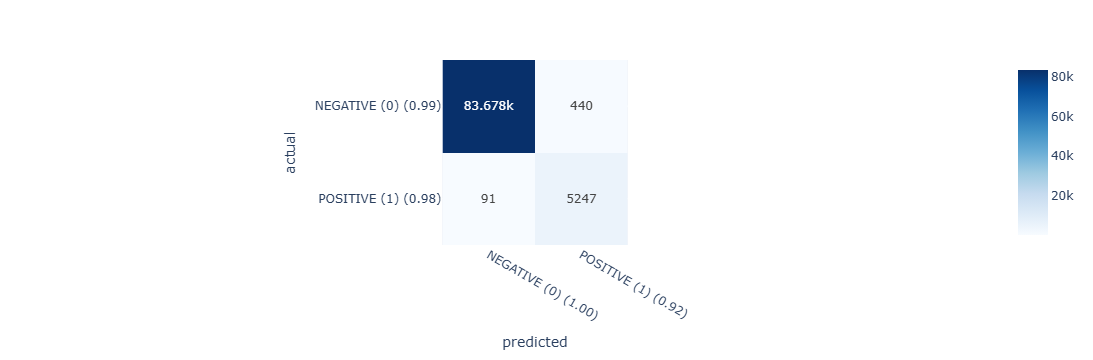

In [33]:
cm = confusion_matrix(y_test.to_numpy(dtype=int), predict_class)#
print(cm)

PX.displayConfusionMatrix(cm, width=900, xaxes={'labels': labels, 'title': 'predicted'}, yaxes={'labels': labels, 'title': 'actual'})

#[[83678   440]
# [   91  5247]]

#83678 + 440 + 91 + 5247
#89456
#91 + 5247
#5338

Die 245 der 867 Dokumente, auf welche sich die gewählten 397 Fragen beziehen, bestehen aus einer Gesamtzahl von 89456 Abschnitten, von denen 5338 eine Grenze darstellen. Durch das Modell wurden 5247 der Grenzen richtig erkannt und 91 als falsch negativ klassifiziert, was einem Recall von 0.983 entspricht. Insgesamt wurden 5687 Grenzen vorhergesagt von denen 440 als falsch positiv klassifiziert wurden und eine Precision von ca. 0.9226 erzielt.

### Sample

Prüfung der Vorhersage für Test-Daten anhand einzelner Beispiele.

Für n Beispiele aus den Testdaten die tatsächlichen Label sowie die durch das Modell vorhergesagten Label ausgeben.

In [21]:
#Beispiel
index = 20

#X_test.iloc[:index]
print('actual')
print(np.array(y_test[0][:index]).tolist())
print('predict')
print(y_test[1][:index])

actual
[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1]
predict
[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1]
